# Tahoe subset → PyTorch train and validation loaders

This notebook reads the subset already saved in Google Drive and creates a reusable train/validation index **in the same Drive folder**. It does not copy the expression dataset to the Colab runtime.

**Default split:** hold out about 20% of observed **(cell line, drug) pairs**. Every cell, dose, and replicate sample for a held-out treated pair goes to validation. The same cell line and drug must each occur in another training pair. DMSO cells are split individually by a stable cell-ID hash so both loaders can include controls. The validation fraction is approximate because conditions have different cell counts.

**Batch fields:** exactly `genes`, `expressions`, `drug`, and `cell_line_id`. `genes[i]` and `expressions[i]` are aligned 1D PyTorch tensors for cell `i`; they are kept sparse and can have different lengths across cells. `drug[i]` and `cell_line_id[i]` are the original string labels. DMSO appears as `drug="DMSO_TF"`; classifier-free guidance masking can be applied in your training loop.

Keep `NUM_WORKERS=0` with the mounted Drive and use the supplied row-group batch sampler. The compact index is written once; later runs reuse it. [Tahoe data format](https://huggingface.co/datasets/tahoebio/Tahoe-100M) · [PyTorch DataLoader](https://docs.pytorch.org/docs/stable/data.html)


## 1. Install and mount Drive

The Colab runtime needs PyArrow and PyTorch. If PyTorch is absent, this notebook installs its CPU package to prepare the data; you can use a GPU runtime with a matching PyTorch installation for training.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pyarrow") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])

import torch
import pyarrow as pa

print("PyTorch:", torch.__version__, "| PyArrow:", pa.__version__)

PyTorch: 2.11.0+cu128 | PyArrow: 23.0.1


In [4]:
!unzip "cfg_25lines_100drugs*.zip" -d /content/raw_tahoe


Archive:  cfg_25lines_100drugs-20260928T160712Z-1-001.zip
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/panel_review.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/stats/overview.png  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/selection_status.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/selection_plan.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/plan.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/stats/summary.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/download_status.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/manifest.json  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/metadata/gene_metadata.parquet  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/cells/part-03385.parquet  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/cells/part-03375.parquet  
  inflating: /content/raw_tahoe/cfg_25lines_100drugs/cells/part-03368.parquet  
  i

In [5]:
from pathlib import Path

DATA_DIR = Path("/content/raw_tahoe/cfg_25lines_100drugs")
parts = sorted((DATA_DIR / "cells").glob("part-*.parquet"))

print("Subset folder exists:", DATA_DIR.is_dir())
print("Raw cell files:", len(parts))
print("First file:", parts[0] if parts else None)
print("PCA ZIP available:", Path("/content/25lines_100drugs_pca_data.zip").exists())

Subset folder exists: True
Raw cell files: 3388
First file: /content/raw_tahoe/cfg_25lines_100drugs/cells/part-00000.parquet
PCA ZIP available: False


In [6]:
import json
from huggingface_hub import hf_hub_download

plan = json.loads((DATA_DIR / "plan.json").read_text())

sample_file = hf_hub_download(
    repo_id="tahoebio/Tahoe-100M",
    repo_type="dataset",
    revision=plan["revision"],
    filename="metadata/sample_metadata.parquet",
    local_dir=DATA_DIR,
)

print("Sample metadata:", sample_file)
print("Exists:", (DATA_DIR / "metadata/sample_metadata.parquet").exists())

Sample metadata: /content/raw_tahoe/cfg_25lines_100drugs/metadata/sample_metadata.parquet
Exists: True


In [ ]:
# Check pca zip:
import json
import numpy as np

split_dir = DATA_DIR / "splits" / "pair_seed42_val20_raw4"
pca_dir = split_dir / "pca50_hvg2000"

split_manifest = json.loads((split_dir / "manifest.json").read_text())
pca_manifest = json.loads((pca_dir / "pca_manifest.json").read_text())

actual_files = sorted(p.name for p in (DATA_DIR / "cells").glob("part-*.parquet"))
expected_files = sorted(split_manifest["config"]["files"])

print("Raw file lists match:", actual_files == expected_files)
print("PCA/split settings match:",
      pca_manifest["config"]["split_config"] == split_manifest["config"])

for split in ["train", "validation"]:
    pcs = np.load(pca_dir / f"pcs_{split}.npy", mmap_mode="r")  # [N_split, 50]
    print(split, "saved PCA cells:", len(pcs))

assert actual_files == expected_files
assert pca_manifest["config"]["split_config"] == split_manifest["config"]

Raw file lists match: False
PCA/split settings match: True
train saved PCA cells: 791249
validation saved PCA cells: 200650


AssertionError: 

In [7]:
actual = set(actual_files)
expected = set(expected_files)

print("Expected raw files:", len(expected))
print("Available raw files:", len(actual))
print("Missing files:", len(expected - actual))
print("Extra files:", len(actual - expected))
print("First 10 missing:", sorted(expected - actual)[:10])
print("First 10 extra:", sorted(actual - expected)[:10])

print("First expected name:", expected_files[0] if expected_files else None)
print("First actual name:", actual_files[0] if actual_files else None)

NameError: name 'actual_files' is not defined

For loading local data only

In [ ]:
import shutil
import zipfile
from pathlib import Path

pca_zip = Path("/content/25lines_100drugs_pca_data.zip")
assert zipfile.is_zipfile(pca_zip), "Wait for the PCA ZIP upload to finish"

pca_extract = Path("/content/pca_subset")
with zipfile.ZipFile(pca_zip) as archive:
    archive.extractall(pca_extract)

pca_subset = (
    pca_extract / "content/data/Tahoe/subsets/cfg_25lines_100drugs"
)
assert (pca_subset / "plan.json").exists()

# Copy bookkeeping, metadata, and saved PCA results.
# The PCA ZIP's cells/ folder is empty; the raw Parquet files stay in DATA_DIR.
shutil.copytree(pca_subset, DATA_DIR, dirs_exist_ok=True)

print("Raw cell files:", len(list((DATA_DIR / "cells").glob("part-*.parquet"))))
print("Plan exists:", (DATA_DIR / "plan.json").exists())
print("Sample metadata exists:", (DATA_DIR / "metadata/sample_metadata.parquet").exists())
print("Existing PCA:", list((DATA_DIR / "splits").rglob("pcs_train.npy")))

Raw cell files: 1273
Plan exists: True
Sample metadata exists: True
Existing PCA: [PosixPath('/content/raw_tahoe/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/pcs_train.npy')]


## 2. Settings

Use the **same subset folder** as your completed download. Choose a different `SPLIT_NAME` if you change the validation fraction or seed. The new default split name creates a four-field index without touching your expression data. The exported dataset must have `complete_expression_scan=true` and no missing selected IDs in `download_status.json`.


In [9]:
SUBSET_NAME = "cfg_25lines_100drugs" # @param {type:"string"}
SPLIT_NAME = "pair_seed42_val20_raw4" # @param {type:"string"}
VALIDATION_FRACTION = 0.20 # @param {type:"number"}
SEED = 42 # @param {type:"integer"}
BATCH_SIZE = 32 # @param {type:"integer"}
for name in (SUBSET_NAME, SPLIT_NAME):
    if not name or Path(name).name != name or name in {".", ".."}:
        raise ValueError("Subset and split names must each be one folder name")
if BATCH_SIZE < 1 or not 0 < VALIDATION_FRACTION < 1:
    raise ValueError("Check the validation fraction and batch size")
DATA_DIR = Path("/content/raw_tahoe") / SUBSET_NAME
SPLIT_DIR = DATA_DIR / "splits" / SPLIT_NAME
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Subset folder not found: {DATA_DIR}")
print("Expression data:", DATA_DIR / "cells")
print("New/reused split index:", SPLIT_DIR)

Expression data: /content/raw_tahoe/cfg_25lines_100drugs/cells
New/reused split index: /content/raw_tahoe/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4


## 3. Editable PyTorch loader code

The loader is defined in the next five executable cells. Edit these functions directly if you want to change the split, indexing, dataset access, or batching. The helper is also available separately as `tahoe_torch_loader.py`; no source string or runtime `exec` is used here.


### 3a. Imports, index schema, and deterministic split rules

The pair split keeps each held-out drug and cell line represented in training. DMSO cells are assigned individually.


In [10]:
from collections import Counter, defaultdict, OrderedDict
import hashlib
import json
import math
import shutil
import tempfile

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import torch
from torch.utils.data import Dataset, DataLoader, Sampler


INDEX_SCHEMA = pa.schema([
    ("file_id", pa.int16()), ("row_group", pa.int16()), ("row", pa.int32()),
    ("line_id", pa.int16()), ("drug_id", pa.int16()), ("split", pa.int8()),
])


def atomic_json(path, obj):
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(obj, indent=2) + "\n")
    temp.replace(path)


def pair_split(pairs, validation_fraction, seed):
    """Hold out pairs while retaining each drug and line elsewhere in training."""
    if not 0 < validation_fraction < 1:
        raise ValueError("Validation fraction must lie between 0 and 1")
    pairs = sorted(set(pairs))
    by_line = Counter(line for line, _ in pairs)
    by_drug = Counter(drug for _, drug in pairs)
    order = list(pairs)
    np.random.default_rng(seed).shuffle(order)
    held_out = set()
    target = max(1, round(validation_fraction * len(pairs)))
    for line, drug in order:
        if len(held_out) >= target:
            break
        if by_line[line] > 1 and by_drug[drug] > 1:
            held_out.add((line, drug))
            by_line[line] -= 1
            by_drug[drug] -= 1
    if not held_out:
        raise ValueError("No drug/line pair can be held out while keeping its drug and line in training")
    return held_out


def control_is_validation(barcode, validation_fraction, seed):
    rank = int.from_bytes(hashlib.blake2b(f"{seed}|{barcode}".encode(), digest_size=8).digest(), "big")
    return rank / 2**64 < validation_fraction



### 3b. Build the compact Drive index

This reads metadata columns from the saved Parquet parts and writes the split index on Drive. It does not duplicate expression arrays.


In [11]:
def prepare_index(data_dir, split_dir, validation_fraction=0.2, seed=42):
    data_dir, split_dir = Path(data_dir), Path(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)
    status = json.loads((data_dir / "download_status.json").read_text())
    if not status.get("complete_expression_scan") or status.get("missing_selected_cells") != 0:
        raise ValueError("Finish exporting the subset before building train/validation loaders")
    plan = json.loads((data_dir / "plan.json").read_text())
    parts = sorted((data_dir / "cells").glob("part-*.parquet"))
    if not parts:
        raise ValueError("No expression Parquet files found")
    config = dict(dataset_revision=plan["revision"], seed=int(seed),
                  validation_fraction=float(validation_fraction), batch_format="raw_sparse_four_fields_v1",
                  files=[p.name for p in parts])
    manifest_path = split_dir / "manifest.json"
    index_path = split_dir / "cell_index.parquet"
    if manifest_path.exists() and index_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if manifest["config"] != config:
            raise ValueError("Split settings/files changed. Use a new split folder to build another split.")
        return manifest

    samples = pq.read_table(data_dir / "metadata/sample_metadata.parquet", columns=["sample", "drug"]).to_pylist()
    sample_drug = {r["sample"]: r["drug"] for r in samples}
    line_names = list(plan["cell_line_ids"])
    drug_names = ["DMSO_TF"] + list(plan["drugs"])
    line_id = {name: i for i, name in enumerate(line_names)}
    drug_id = {name: i for i, name in enumerate(drug_names)}
    coverage = json.loads((data_dir / "coverage_report.json").read_text())
    observed_pairs = {(r["cell_line_id"], sample_drug[r["sample"]]) for r in coverage
                      if r["saved"] > 0 and sample_drug[r["sample"]] != "DMSO_TF"}
    validation_pairs = pair_split(observed_pairs, validation_fraction, seed)

    # Stage only the compact numeric index on the Colab VM, then copy it once
    # to Drive. Expression data always remains on Drive.
    counts = Counter()
    with tempfile.TemporaryDirectory() as temporary:
        staging = Path(temporary) / "cell_index.parquet"
        with pq.ParquetWriter(staging, INDEX_SCHEMA, compression="zstd") as writer:
            for file_id, path in enumerate(parts):
                pf = pq.ParquetFile(path)
                for rg in range(pf.num_row_groups):
                    meta = pf.read_row_group(rg, columns=["drug", "cell_line_id",
                                                          "BARCODE_SUB_LIB_ID"]).to_pydict()
                    n = len(meta["drug"])
                    if not n:
                        continue
                    train_val = []
                    for line, drug, barcode in zip(
                            meta["cell_line_id"], meta["drug"], meta["BARCODE_SUB_LIB_ID"]):
                        if drug not in drug_id or line not in line_id:
                            raise ValueError(f"Unexpected condition in {path.name}")
                        validation = ((line, drug) in validation_pairs if drug != "DMSO_TF"
                                      else control_is_validation(barcode, validation_fraction, seed))
                        train_val.append(int(validation))
                        counts[("validation" if validation else "train", "control" if drug == "DMSO_TF" else "treated")] += 1
                    columns = dict(file_id=np.full(n, file_id, np.int16), row_group=np.full(n, rg, np.int16),
                                   row=np.arange(n, dtype=np.int32),
                                   line_id=np.array([line_id[x] for x in meta["cell_line_id"]], np.int16),
                                   drug_id=np.array([drug_id[x] for x in meta["drug"]], np.int16),
                                   split=np.asarray(train_val, dtype=np.int8))
                    writer.write_table(pa.Table.from_pydict(columns, schema=INDEX_SCHEMA))

        temporary_drive_path = split_dir / "cell_index.parquet.tmp"
        shutil.copyfile(staging, temporary_drive_path)
        temporary_drive_path.replace(index_path)

    saved = sum(counts.values())
    if saved != status["saved_cells"]:
        index_path.unlink(missing_ok=True)
        raise ValueError(f"Index has {saved} cells but download status reports {status['saved_cells']}")
    manifest = dict(config=config, line_names=line_names, drug_names=drug_names,
                    validation_pairs=sorted([list(x) for x in validation_pairs]),
                    counts={f"{split}_{kind}": int(n) for (split, kind), n in counts.items()},
                    cell_index_file="cell_index.parquet")
    if counts[("train", "treated")] == 0 or counts[("validation", "treated")] == 0:
        index_path.unlink(missing_ok=True)
        raise ValueError("Both splits need treated cells")
    atomic_json(manifest_path, manifest)
    return manifest



### 3c. Dataset: fetch sparse expression rows lazily

This class reads one Parquet row group at a time from Drive and caches two groups.


In [12]:
class TahoeCells(Dataset):
    def __init__(self, data_dir, split_dir, split):
        self.data_dir = Path(data_dir)
        self.manifest = json.loads((Path(split_dir) / "manifest.json").read_text())
        table = pq.read_table(Path(split_dir) / self.manifest["cell_index_file"])
        index = table.to_pydict()
        selected = np.flatnonzero(np.asarray(index["split"]) == (0 if split == "train" else 1))
        if split not in {"train", "validation"} or not len(selected):
            raise ValueError("Unknown or empty split")
        self.index = {k: np.asarray(v)[selected] for k, v in index.items()}
        self.parts = [self.data_dir / "cells" / name for name in self.manifest["config"]["files"]]
        self.fragments = defaultdict(list)
        for position, (file_id, group) in enumerate(zip(self.index["file_id"], self.index["row_group"])):
            self.fragments[(int(file_id), int(group))].append(position)
        self.cache = OrderedDict()

    def __len__(self):
        return len(self.index["row"])

    def __getitem__(self, position):
        file_id, group, row = (int(self.index[k][position]) for k in ("file_id", "row_group", "row"))
        key = (file_id, group)
        if key not in self.cache:
            self.cache[key] = pq.ParquetFile(self.parts[file_id]).read_row_group(
                group, columns=["genes", "expressions"])
            if len(self.cache) > 2:
                self.cache.popitem(last=False)
        table = self.cache[key]
        genes = np.asarray(table["genes"][row].as_py(), dtype=np.int64)
        values = np.asarray(table["expressions"][row].as_py(), dtype=np.float32)
        if len(genes) != len(values) or np.any(values < 0):
            raise ValueError("Malformed sparse expression row")
        return (torch.from_numpy(genes), torch.from_numpy(values),
                self.manifest["drug_names"][int(self.index["drug_id"][position])],
                self.manifest["line_names"][int(self.index["line_id"][position])])



### 3d. Batch sampler: group reads by Parquet row group

Training batches reshuffle by row group each epoch; validation order stays fixed.


In [13]:
class FragmentBatches(Sampler):
    def __init__(self, dataset, batch_size, shuffle, seed):
        self.dataset, self.batch_size, self.shuffle, self.seed = dataset, batch_size, shuffle, seed
        self.epoch = 0
        if batch_size < 1:
            raise ValueError("batch_size must be positive")

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1
        fragments = list(self.dataset.fragments)
        if self.shuffle:
            rng.shuffle(fragments)
        for key in fragments:
            positions = np.asarray(self.dataset.fragments[key], dtype=np.int64)
            if self.shuffle:
                rng.shuffle(positions)
            for start in range(0, len(positions), self.batch_size):
                yield positions[start:start + self.batch_size].tolist()

    def __len__(self):
        return sum(math.ceil(len(v) / self.batch_size) for v in self.dataset.fragments.values())



### 3e. Collate sparse rows into four-field batches and create loaders

Each batch contains only `genes`, `expressions`, `drug`, and `cell_line_id`. Gene and expression tensors stay as per-cell lists because sparse rows can have different lengths.


In [14]:
def collate_raw_four(cells):
    """Keep sparse rows ragged and expose exactly the four requested fields."""
    return {
        "genes": [cell[0] for cell in cells],
        "expressions": [cell[1] for cell in cells],
        "drug": [cell[2] for cell in cells],
        "cell_line_id": [cell[3] for cell in cells],
    }


def make_loaders(data_dir, split_dir, batch_size=32, seed=42):
    manifest = json.loads((Path(split_dir) / "manifest.json").read_text())
    train = TahoeCells(data_dir, split_dir, "train")
    validation = TahoeCells(data_dir, split_dir, "validation")
    train_loader = DataLoader(train, batch_sampler=FragmentBatches(train, batch_size, True, seed),
                              collate_fn=collate_raw_four, num_workers=0)
    validation_loader = DataLoader(validation, batch_sampler=FragmentBatches(validation, batch_size, False, seed),
                                   collate_fn=collate_raw_four, num_workers=0)
    return train_loader, validation_loader, manifest



## 4. Build or reuse the split index

This reads the cell line, drug, and cell ID metadata from saved Parquet parts and creates `splits/<name>/cell_index.parquet` and `manifest.json` on Drive. The cell ID is used only to assign DMSO cells consistently. Sparse expression lists stay in `cells/`. On a fresh subset, index creation may take several minutes because Drive must open many part files.


In [15]:
manifest = prepare_index(DATA_DIR, SPLIT_DIR, VALIDATION_FRACTION, SEED)
print("Split counts:", manifest["counts"])
print("Held-out treated pairs:", len(manifest["validation_pairs"]))
print("Index saved to:", SPLIT_DIR / "cell_index.parquet")


Split counts: {'train_treated': 681817, 'validation_treated': 173108, 'train_control': 109432, 'validation_control': 27542}
Held-out treated pairs: 500
Index saved to: /content/raw_tahoe/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/cell_index.parquet


### 4a. Cell counts and condition distributions

Read only the saved split index. The tables show cell counts and percentages of **all cells within each split** for every cell line and drug. DMSO is listed as `DMSO_TF`; a separate table shows its counts for each cell line. This does not read expression arrays.


In [16]:
import pandas as pd

index_file = SPLIT_DIR / manifest["cell_index_file"]
index_parquet = pq.ParquetFile(index_file)
line_counts = np.zeros((2, len(manifest["line_names"])), dtype=np.int64)
drug_counts = np.zeros((2, len(manifest["drug_names"])), dtype=np.int64)
split_counts = np.zeros(2, dtype=np.int64)
dmso_counts = np.zeros((2, len(manifest["line_names"])), dtype=np.int64)
dmso_id = manifest["drug_names"].index("DMSO_TF")

for row_group in range(index_parquet.num_row_groups):
    columns = index_parquet.read_row_group(
        row_group, columns=["split", "line_id", "drug_id"])
    split_values = columns["split"].to_numpy()
    line_values = columns["line_id"].to_numpy()
    drug_values = columns["drug_id"].to_numpy()
    for split_id in (0, 1):
        selected = split_values == split_id
        split_counts[split_id] += int(selected.sum())
        line_counts[split_id] += np.bincount(
            line_values[selected], minlength=line_counts.shape[1])
        drug_counts[split_id] += np.bincount(
            drug_values[selected], minlength=drug_counts.shape[1])
        dmso_counts[split_id] += np.bincount(
            line_values[selected & (drug_values == dmso_id)],
            minlength=dmso_counts.shape[1])

assert split_counts.sum() == sum(manifest["counts"].values())
assert dmso_counts[0].sum() == manifest["counts"].get("train_control", 0)
assert dmso_counts[1].sum() == manifest["counts"].get("validation_control", 0)
print(f"Training cells: {split_counts[0]:,} ({100 * split_counts[0] / split_counts.sum():.1f}%)")
print(f"Validation cells: {split_counts[1]:,} ({100 * split_counts[1] / split_counts.sum():.1f}%)")
print(f"Cell lines represented (train / validation): "
      f"{np.count_nonzero(line_counts[0])} / {np.count_nonzero(line_counts[1])}")
print(f"Drugs represented, including DMSO (train / validation): "
      f"{np.count_nonzero(drug_counts[0])} / {np.count_nonzero(drug_counts[1])}")

def distribution_table(names, counts, label):
    table = pd.DataFrame({
        "train_cells": counts[0],
        "validation_cells": counts[1],
        "train_pct": np.round(100 * counts[0] / split_counts[0], 2),
        "validation_pct": np.round(100 * counts[1] / split_counts[1], 2),
    }, index=pd.Index(names, name=label))
    table["total_cells"] = table["train_cells"] + table["validation_cells"]
    return table.sort_values("total_cells", ascending=False)

cell_line_distribution = distribution_table(manifest["line_names"], line_counts, "cell_line_id")
drug_distribution = distribution_table(manifest["drug_names"], drug_counts, "drug")
print("\nCell line distribution:")
print(cell_line_distribution.to_string())
print("\nDrug distribution:")
print(drug_distribution.to_string())

print("\nDMSO (DMSO_TF) cells by cell line:")
dmso_by_line = pd.DataFrame({
    "train_DMSO": dmso_counts[0],
    "validation_DMSO": dmso_counts[1],
}, index=pd.Index(manifest["line_names"], name="cell_line_id"))
print(dmso_by_line.to_string())
if np.any(dmso_counts.sum(axis=0) == 0):
    print("Some cell lines have no DMSO cells in the saved subset; check the table above.")
if np.any(dmso_counts.sum(axis=1) == 0):
    print("One split has no DMSO cells; check the table above before training.")


Training cells: 791,249 (79.8%)
Validation cells: 200,650 (20.2%)
Cell lines represented (train / validation): 25 / 25
Drugs represented, including DMSO (train / validation): 101 / 101

Cell line distribution:
              train_cells  validation_cells  train_pct  validation_pct  total_cells
cell_line_id                                                                       
CVCL_0459           32614              7723       4.12            3.85        40337
CVCL_0399           32287              8004       4.08            3.99        40291
CVCL_0293           30563              9692       3.86            4.83        40255
CVCL_1731           31512              8726       3.98            4.35        40238
CVCL_0023           31704              8532       4.01            4.25        40236
CVCL_1381           33754              6479       4.27            3.23        40233
CVCL_0366           34482              5748       4.36            2.86        40230
CVCL_0152           33374         

## 5. Create PyTorch loaders and inspect one batch

The custom sampler groups each batch by saved Parquet row group to reduce Drive reads. Training order reshuffles each epoch; validation order is fixed. `NUM_WORKERS=0` keeps Drive access within the notebook process.


In [17]:
train_loader, validation_loader, manifest = make_loaders(
    DATA_DIR, SPLIT_DIR, batch_size=BATCH_SIZE, seed=SEED)
print("Training cells:", len(train_loader.dataset), "| Validation cells:", len(validation_loader.dataset))
print("Training batches:", len(train_loader), "| Validation batches:", len(validation_loader))
for name, loader in [("train", train_loader), ("validation", validation_loader)]:
    batch = next(iter(loader))
    assert set(batch) == {"genes", "expressions", "drug", "cell_line_id"}
    print(name, "cells:", len(batch["drug"]),
          "first cell sparse genes:", len(batch["genes"][0]),
          "drug:", batch["drug"][0],
          "cell line:", batch["cell_line_id"][0])


Training cells: 791249 | Validation cells: 200650
Training batches: 26373 | Validation batches: 7932
train cells: 32 first cell sparse genes: 1164 drug: Adagrasib cell line: CVCL_0218
validation cells: 32 first cell sparse genes: 1410 drug: Retinoic acid cell line: CVCL_1097


## 6. Use the loaders in training

The loaders stay lazy: constructing them does not read expression for every cell. A batch has four fields only. `batch["genes"]` and `batch["expressions"]` are lists of aligned 1D tensors, one pair per cell, containing Tahoe gene token IDs and raw expression values. `batch["drug"]` and `batch["cell_line_id"]` are lists of strings. Move the tensors you need to your device inside the training loop; encode the string conditions for your model there.

Fit any normalization or vocabulary using training cells only. The pair holdout retains each drug and cell line in training, so categorical labels can support this validation design. Evaluating entirely unseen drugs requires chemical features such as SMILES.


In [18]:
# Example of consuming one cell from a batch; insert your model/optimizer here.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch = next(iter(train_loader))
genes = batch["genes"][0].to(device)
expressions = batch["expressions"][0].to(device)
drug = batch["drug"][0]
cell_line_id = batch["cell_line_id"][0]
print("Ready for your model:", genes.shape, expressions.shape, drug, cell_line_id, device)


Ready for your model: torch.Size([1397]) torch.Size([1397]) Docetaxel CVCL_1239 cuda


## Resume and interpretation

After a Colab disconnect, rerun the notebook cells. The saved index is reused if settings and part-file list match. Train/validation membership is deterministic for the seed. The compact index and split counts are kept on Drive under the subset's `splits/` folder. The expression Parquet parts remain shared by both loaders and are read lazily. Your earlier split folder is preserved; the new default name builds a separate four-field index.

Pair holdout keeps every dose of a treated pair together. DMSO cells are divided individually so controls can appear in both splits. This is a cell-level DMSO validation split, not a held-out DMSO replicate or plate. For batch-generalization claims, use a different validation design.

**Verified locally:** a small synthetic export was indexed, split, read into actual PyTorch batches, and checked for pair leakage. Your full Drive subset is accessible only in your Colab account and was not processed here.


## 7. Train on 50 PCs of the 2,000 highly variable genes (HVGs)

Sections 1–6 give **raw sparse expression**. Diffusion and flow-matching models are easier to train on a dense, low-dimensional vector, so this section builds one: **the top 50 principal components of the 2,000 most variable genes**, with the same preprocessing as `data_processing.py`:

1. per-cell library-size normalisation to 10,000 (over the stored genes), then `log1p`;
2. Seurat-style binned-dispersion selection of the top 2,000 HVGs;
3. z-score each HVG (mean/std before clipping), clip at ±10;
4. PCA to 50 components.

**Everything is fitted on the training split only** (HVGs, scaler and PCA); validation cells are only projected. The data are streamed from the loaders in three passes: (1) per-gene statistics → HVGs and scaler, (2) the exact PCA via the 2,000×2,000 covariance, (3) projection of every train and validation cell. Results are cached in `SPLIT_DIR/pca50_hvg2000/` and reused on later runs if the settings match.

**Outputs per cell:** `pcs` (50 floats, divided by one global train-set scalar `pc_scale` so the overall variance is ~1), `drug`, `cell_line_id`, `is_control`, and `cluster`.

**`cluster`:** for every non-DMSO (cell line, drug) pair, k-means (k=3) is run on that pair's raw 50-PC vectors, and `cluster` is the nearest centroid. Ids are ordered by centroid distance to that cell line's DMSO centroid (train DMSO cells only): `0` is the least perturbed and `2` the most perturbed. DMSO cells get `-1`. The pair split keeps every treated pair wholly inside one split, so no k-means fit mixes train and validation cells. Note that a held-out pair's labels come from its own (validation) cells; that follows from the definition.

In [ ]:
from itertools import islice
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from torch.utils.data import BatchSampler, RandomSampler, SequentialSampler
from tqdm.auto import tqdm

N_HVG = 2000            # highly variable genes kept
N_PCS = 50              # principal components kept
TARGET_SUM = 1e4        # library-size normalisation target
CLIP = 10.0             # z-score clip, as in Scanpy's scale()
CLUSTER_K = 3           # k-means clusters per (cell line, drug) pair
CLUSTER_N_INIT = 10
FIT_BATCH_SIZE = 256    # cells per batch while streaming (does not change results)
MAX_BATCHES = None      # e.g. 200 for a quick smoke test; results are then partial and go to a separate folder

PCA_DIR = SPLIT_DIR / (f"pca{N_PCS}_hvg{N_HVG}" + ("_smoke" if MAX_BATCHES else ""))
PCA_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pca_config = json.loads(json.dumps(dict(
    split_name=SPLIT_NAME, split_config=manifest["config"],
    n_hvg=N_HVG, n_pcs=N_PCS, target_sum=TARGET_SUM, clip=CLIP,
    cluster_k=CLUSTER_K, cluster_n_init=CLUSTER_N_INIT, cluster_seed=SEED, max_batches=MAX_BATCHES,
    label_rule="kmeans_raw_pcs_per_pair_ordered_by_distance_to_train_dmso_centroid_v1")))
print("PCA outputs:", PCA_DIR, "| device:", PCA_DEVICE)


PCA outputs: /content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000 | device: cpu


### 7a. Helpers: normalisation, HVG selection, PCA from moments

`flatten_batch` turns a ragged batch into flat arrays and applies library-size normalisation and `log1p`. `select_hvgs` is a port of the binned-dispersion block in `data_processing.py`. `pca_from_moments` gives the exact PCA from the sum and Gram matrix of the scaled data.

In [ ]:
def atomic_npy(path, array):
    temp = path.with_name(path.name + ".tmp")
    with open(temp, "wb") as handle:
        np.save(handle, array)
    temp.replace(path)


def atomic_npz(path, **arrays):
    temp = path.with_name(path.name + ".tmp")
    with open(temp, "wb") as handle:
        np.savez(handle, **arrays)
    temp.replace(path)


def make_pass_loader(dataset, batch_size, shuffle=False, seed=SEED):
    return DataLoader(dataset, batch_sampler=FragmentBatches(dataset, batch_size, shuffle, seed),
                      collate_fn=collate_raw_four, num_workers=0)


def flatten_batch(batch):
    """Ragged batch -> flat arrays. Returns cell index, gene token, normalised x, log1p(x), n_cells."""
    n_cells = len(batch["genes"])
    lengths = np.fromiter((len(g) for g in batch["genes"]), dtype=np.int64, count=n_cells)
    genes = torch.cat(batch["genes"]).numpy()
    counts = torch.cat(batch["expressions"]).numpy().astype(np.float64)
    cell = np.repeat(np.arange(n_cells), lengths)
    totals = np.bincount(cell, weights=counts, minlength=n_cells)
    totals[totals == 0] = 1.0
    x = counts * (TARGET_SUM / totals[cell])
    return cell, genes, x, np.log1p(x), n_cells


def densify_hvg(log_values, cell, genes, n_cells, hvg_col):
    """Scatter the HVG entries of a batch into a dense (n_cells, n_hvg) log-normalised array."""
    col = np.full(genes.shape, -1, dtype=np.int64)
    in_range = genes < len(hvg_col)
    col[in_range] = hvg_col[genes[in_range]]
    keep = col >= 0
    dense = np.zeros((n_cells, int(hvg_col.max()) + 1), dtype=np.float32)
    dense[cell[keep], col[keep]] = log_values[keep]
    return dense


def standardise(dense, scaler_mean, scaler_std):
    z = (dense - scaler_mean) / scaler_std
    return np.clip(z, -CLIP, CLIP, out=z)


def select_hvgs(gene_mean, gene_var, gene_ids, n_top):
    """Seurat-flavour HVGs: dispersion normalised within 20 bins of mean expression."""
    mean = gene_mean.copy()
    mean[mean == 0] = 1e-12
    dispersion = gene_var / mean
    dispersion[dispersion == 0] = np.nan
    with np.errstate(invalid="ignore", divide="ignore"):
        log_dispersion = np.log(dispersion)
    disp_df = pd.DataFrame({"mean_expr": np.log1p(gene_mean), "dispersion": log_dispersion})
    disp_df["mean_bin"] = pd.cut(disp_df["mean_expr"], bins=20)
    bin_stats = disp_df.groupby("mean_bin", observed=True)["dispersion"].agg(bin_mean="mean", bin_std="std")
    single = bin_stats["bin_std"].isna() | (bin_stats["bin_std"] == 0)
    bin_stats.loc[single, "bin_std"] = bin_stats.loc[single, "bin_mean"]
    bin_stats.loc[single, "bin_mean"] = 0.0
    disp_df = disp_df.join(bin_stats, on="mean_bin")
    disp_df["dispersion_norm"] = (disp_df["dispersion"] - disp_df["bin_mean"]) / disp_df["bin_std"]
    disp_df["dispersion_norm"] = disp_df["dispersion_norm"].fillna(disp_df["dispersion_norm"].min() - 1)
    positions = disp_df["dispersion_norm"].nlargest(min(n_top, len(gene_ids))).index.to_numpy()
    return gene_ids[positions]


def pca_from_moments(S1, S2, n, n_pcs):
    """Exact PCA from sum (S1) and Gram matrix (S2) of n rows: centre, eigendecompose, sign-fix."""
    S1, S2 = np.asarray(S1, np.float64), np.asarray(S2, np.float64)
    mu = S1 / n
    cov = (S2 - n * np.outer(mu, mu)) / (n - 1)
    values, vectors = np.linalg.eigh(cov)
    order = np.argsort(values)[::-1][:n_pcs]
    components = vectors[:, order].T.copy()
    signs = np.sign(components[np.arange(n_pcs), np.abs(components).argmax(axis=1)])
    signs[signs == 0] = 1.0
    components *= signs[:, None]
    variance = values[order]
    return mu, components, variance, variance / np.trace(cov)


### 7b. Passes 1 and 2: HVGs, scaler and PCA (training cells only)

Pass 1 accumulates per-gene sums over all training cells to pick the HVGs and to get the scaler mean and std. Pass 2 z-scores each cell's HVG values (zeros included), clips them, and accumulates the sum and Gram matrix. The PCA is the eigendecomposition of the resulting covariance.

In [ ]:
def fit_hvgs_and_scaler(dataset, max_batches=None):
    loader = make_pass_loader(dataset, FIT_BATCH_SIZE)
    acc = np.zeros((5, 1 << 16))           # sum x, sum x^2, sum log1p(x), sum log1p(x)^2, cells with gene
    n_cells = 0
    for batch in tqdm(islice(loader, max_batches), total=min(len(loader), max_batches or len(loader)),
                      desc="pass 1: gene statistics"):
        cell, genes, x, log_x, b = flatten_batch(batch)
        if genes.max() >= acc.shape[1]:
            acc = np.pad(acc, ((0, 0), (0, int(genes.max()) + 1 - acc.shape[1])))
        for row, weights in enumerate((x, x * x, log_x, log_x * log_x, None)):
            acc[row] += np.bincount(genes, weights=weights, minlength=acc.shape[1])
        n_cells += b
    sx, sxx, sl, sll, seen_count = acc
    seen = np.flatnonzero(seen_count > 0)
    mean = sx[seen] / n_cells
    var = np.maximum((sxx[seen] / n_cells - mean ** 2) * (n_cells / (n_cells - 1)), 0.0)
    hvg_ids = select_hvgs(mean, var, seen, N_HVG).astype(np.int64)
    scaler_mean = sl[hvg_ids] / n_cells
    scaler_std = np.sqrt(np.maximum(sll[hvg_ids] / n_cells - scaler_mean ** 2, 0.0))
    scaler_std[scaler_std == 0] = 1.0
    return hvg_ids, scaler_mean.astype(np.float32), scaler_std.astype(np.float32), n_cells


def make_hvg_col(hvg_ids):
    hvg_col = np.full(int(hvg_ids.max()) + 1, -1, dtype=np.int64)
    hvg_col[hvg_ids] = np.arange(len(hvg_ids))
    return hvg_col


def fit_pca(dataset, hvg_ids, scaler_mean, scaler_std, max_batches=None, chunk_rows=8192):
    hvg_col = make_hvg_col(hvg_ids)
    loader = make_pass_loader(dataset, FIT_BATCH_SIZE)
    S1 = torch.zeros(len(hvg_ids), dtype=torch.float64, device=PCA_DEVICE)
    S2 = torch.zeros(len(hvg_ids), len(hvg_ids), dtype=torch.float64, device=PCA_DEVICE)
    buffer, buffered, n_cells = [], 0, 0

    def flush():
        z = torch.from_numpy(np.concatenate(buffer)).to(PCA_DEVICE)
        S1.add_(z.sum(dim=0, dtype=torch.float64))
        S2.add_((z.T @ z).double())
        buffer.clear()

    for batch in tqdm(islice(loader, max_batches), total=min(len(loader), max_batches or len(loader)),
                      desc="pass 2: PCA moments"):
        cell, genes, x, log_x, b = flatten_batch(batch)
        buffer.append(standardise(densify_hvg(log_x, cell, genes, b, hvg_col), scaler_mean, scaler_std))
        buffered += b
        n_cells += b
        if buffered >= chunk_rows:
            flush()
            buffered = 0
    if buffer:
        flush()
    mu, components, variance, ratio = pca_from_moments(S1.cpu().numpy(), S2.cpu().numpy(), n_cells, N_PCS)
    return mu.astype(np.float32), components.astype(np.float32), variance, ratio


### 7c. Pass 3 and cluster labels

`project_split` projects every cell of a split to PCs, writing each cell at its dataset position. `assign_pair_clusters` runs k-means per treated (cell line, drug) pair and orders the clusters by distance to the train DMSO centroid.

In [ ]:
def project_split(dataset, model, max_batches=None, desc="pass 3"):
    batches = list(FragmentBatches(dataset, FIT_BATCH_SIZE, False, SEED))[:max_batches]
    loader = DataLoader(dataset, batch_sampler=batches, collate_fn=collate_raw_four, num_workers=0)
    pcs = np.full((len(dataset), N_PCS), np.nan, dtype=np.float32)
    for positions, batch in tqdm(zip(batches, loader), total=len(batches), desc=desc):
        cell, genes, x, log_x, b = flatten_batch(batch)
        z = standardise(densify_hvg(log_x, cell, genes, b, model["hvg_col"]),
                        model["scaler_mean"], model["scaler_std"])
        pcs[positions] = (z - model["pca_mean"]) @ model["components"].T
    return pcs


def dmso_reference(pcs, line_id, drug_id, n_lines, dmso_id=0):
    """Mean train DMSO PC vector per cell line; lines without DMSO fall back to the pooled mean."""
    valid = np.isfinite(pcs).all(axis=1)
    dmso = valid & (drug_id == dmso_id)
    if not dmso.any():
        raise ValueError("No DMSO training cells with PCs; cannot order clusters")
    reference = np.tile(pcs[dmso].mean(axis=0), (n_lines, 1))
    for line in range(n_lines):
        rows = dmso & (line_id == line)
        if rows.any():
            reference[line] = pcs[rows].mean(axis=0)
    return reference


def assign_pair_clusters(pcs, line_id, drug_id, reference, dmso_id=0):
    """k-means per treated (line, drug) pair on raw PCs; ids ordered by centroid distance to DMSO."""
    cluster = np.full(len(pcs), -1, dtype=np.int16)
    valid = np.isfinite(pcs).all(axis=1)
    treated = np.flatnonzero(valid & (drug_id != dmso_id))
    key = line_id[treated].astype(np.int64) * (int(drug_id.max()) + 1) + drug_id[treated]
    treated = treated[np.argsort(key, kind="stable")]
    key = np.sort(key, kind="stable")
    for rows in tqdm(np.split(treated, np.flatnonzero(np.diff(key)) + 1), desc="k-means per pair"):
        if not len(rows):
            continue
        points = pcs[rows].astype(np.float64)
        k = min(CLUSTER_K, len(np.unique(points, axis=0)))
        if k < 2:
            cluster[rows] = 0
            continue
        fit = KMeans(n_clusters=k, n_init=CLUSTER_N_INIT, random_state=SEED).fit(points)
        distance = np.linalg.norm(fit.cluster_centers_ - reference[line_id[rows[0]]], axis=1)
        new_id = np.empty(k, dtype=np.int64)
        new_id[np.argsort(distance, kind="stable")] = np.arange(k)
        cluster[rows] = new_id[fit.labels_]
    return cluster


### 7d. Build or reuse the PCA outputs

Runs the three passes and the clustering once, writes the results next to the split index, and writes `pca_manifest.json` last. A later run with identical settings reloads the saved arrays instead. For a quick trial, set `MAX_BATCHES` in the settings cell above; it writes to a separate `_smoke` folder and the results are partial.

In [ ]:
def build_pca_outputs(train_ds, val_ds):
    manifest_path = PCA_DIR / "pca_manifest.json"
    if manifest_path.exists():
        if json.loads(manifest_path.read_text())["config"] != pca_config:
            raise ValueError("PCA settings changed. Use a new PCA_DIR (change N_HVG/N_PCS/MAX_BATCHES) "
                             "or delete this folder.")
        print("Reusing saved PCA outputs from", PCA_DIR)
        return
    PCA_DIR.mkdir(parents=True, exist_ok=True)
    hvg_ids, scaler_mean, scaler_std, n_fit = fit_hvgs_and_scaler(train_ds, MAX_BATCHES)
    print(f"Pass 1 done: {n_fit:,} training cells, {len(hvg_ids)} HVGs")
    pca_mean, components, variance, ratio = fit_pca(train_ds, hvg_ids, scaler_mean, scaler_std, MAX_BATCHES)
    print(f"Pass 2 done: {N_PCS} PCs capture {100 * ratio.sum():.1f}% of the HVG variance")
    model = dict(hvg_ids=hvg_ids, hvg_col=make_hvg_col(hvg_ids), scaler_mean=scaler_mean,
                 scaler_std=scaler_std, pca_mean=pca_mean, components=components)
    datasets = {"train": train_ds, "validation": val_ds}
    pcs = {name: project_split(ds, model, MAX_BATCHES, f"pass 3: {name}") for name, ds in datasets.items()}
    finite_train = pcs["train"][np.isfinite(pcs["train"]).all(axis=1)]
    pc_scale = float(np.sqrt(finite_train.var(axis=0, dtype=np.float64).mean()))

    line = {name: ds.index["line_id"].astype(np.int64) for name, ds in datasets.items()}
    drug = {name: ds.index["drug_id"].astype(np.int64) for name, ds in datasets.items()}
    assert manifest["drug_names"][0] == "DMSO_TF"
    n_drugs = len(manifest["drug_names"])
    pair_keys = {name: np.unique(line[name][drug[name] != 0] * n_drugs + drug[name][drug[name] != 0]) for name in datasets}
    assert not np.intersect1d(pair_keys["train"], pair_keys["validation"]).size, "A treated pair is in both splits"
    reference = dmso_reference(pcs["train"], line["train"], drug["train"], len(manifest["line_names"]))
    clusters = {name: assign_pair_clusters(pcs[name], line[name], drug[name], reference) for name in datasets}

    atomic_npz(PCA_DIR / "pca_model.npz", hvg_ids=hvg_ids, scaler_mean=scaler_mean, scaler_std=scaler_std,
               pca_mean=pca_mean, components=components, explained_variance=variance,
               explained_variance_ratio=ratio, pc_scale=np.float64(pc_scale), dmso_reference=reference)
    for name in datasets:
        atomic_npy(PCA_DIR / f"pcs_{name}.npy", pcs[name])
        atomic_npy(PCA_DIR / f"cluster_{name}.npy", clusters[name])
    atomic_json(manifest_path, dict(
        config=pca_config, pc_scale=pc_scale, n_fit_cells=int(n_fit),
        counts={name: int(len(pcs[name])) for name in datasets},
        files=["pca_model.npz", "pcs_train.npy", "pcs_validation.npy",
               "cluster_train.npy", "cluster_validation.npy"]))
    print("Saved PCA outputs to", PCA_DIR)


build_pca_outputs(train_loader.dataset, validation_loader.dataset)


pass 1: gene statistics:   0%|          | 0/4610 [00:00<?, ?it/s]

Pass 1 done: 791,249 training cells, 2000 HVGs


pass 2: PCA moments:   0%|          | 0/4610 [00:00<?, ?it/s]

Pass 2 done: 50 PCs capture 28.4% of the HVG variance


pass 3: train:   0%|          | 0/4610 [00:00<?, ?it/s]

pass 3: validation:   0%|          | 0/3388 [00:00<?, ?it/s]

k-means per pair:   0%|          | 0/2000 [00:00<?, ?it/s]

k-means per pair:   0%|          | 0/500 [00:00<?, ?it/s]

Saved PCA outputs to /content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000


# My added in code

download dosages as well

In [22]:
# Export one dose (uM) per cell, in exactly the same row order as the PCA arrays.
# Dose comes from `drugname_drugconc` in sample_metadata.parquet, joined to each cell through its `sample` id.
import re

DOSE_RE = re.compile(r"[,\s]([0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?)\s*[,'\"\s]+uM", re.IGNORECASE)


def parse_dose_um(value):
    """drugname_drugconc -> dose in uM, e.g. "[('Trametinib', 0.05, 'uM')]" -> 0.05."""
    if isinstance(value, (list, tuple)) and len(value) == 1:
        value = value[0]
    if isinstance(value, (list, tuple)) and len(value) == 3 and isinstance(value[1], (int, float)):
        if str(value[2]).lower() != "um":
            raise ValueError(f"Unexpected dose unit in drugname_drugconc={value!r}")
        return float(value[1])
    match = DOSE_RE.search(str(value))
    if match is None:
        raise ValueError(f"Cannot parse a uM dose from drugname_drugconc={value!r}")
    return float(match.group(1))


part_columns = pq.ParquetFile(train_loader.dataset.parts[0]).schema_arrow.names
if "sample" not in part_columns:
   raise ValueError(f"Cell parts have no 'sample' column to join on; columns are {part_columns}")

meta = pq.read_table(DATA_DIR / "metadata/sample_metadata.parquet", columns=["sample", "drugname_drugconc"])
sample_dose = {}
for sample_id, raw in zip(meta["sample"].to_pylist(), meta["drugname_drugconc"].to_pylist()):
    sample_dose[sample_id] = parse_dose_um(raw)
print("Parsed doses for", len(sample_dose), "samples; unique doses (uM):", sorted(set(sample_dose.values())))

# Export one dose per cell, in exactly the same row order as the PCA arrays.
for split, raw_ds in [
    ("train", train_loader.dataset),
    ("validation", validation_loader.dataset),
]:
    doses = np.full(len(raw_ds), np.nan, dtype=np.float32)  # [N_split]

    for (file_id, group_id), positions in raw_ds.fragments.items():
        sample_column = pq.ParquetFile(raw_ds.parts[file_id]).read_row_group(group_id, columns=["sample"])["sample"].to_pylist()

        row_numbers = raw_ds.index["row"][positions]  # [cells in this row group]
        doses[positions] = [sample_dose[sample_column[r]] for r in row_numbers]

    pcs = np.load(PCA_DIR / f"pcs_{split}.npy", mmap_mode="r")  # [N_split, 50]
    assert len(doses) == len(pcs)
    assert np.isfinite(doses).all(), f"Missing doses in {split}"

    np.save(PCA_DIR / f"dose_{split}.npy", doses)  # [N_split]
    print(split, "doses:", np.unique(doses))

Parsed doses for 1344 samples; unique doses (uM): [0.0, 0.05, 0.5, 5.0]
train doses: [0.   0.05 0.5  5.  ]
validation doses: [0.   0.05 0.5  5.  ]


In [ ]:
manifest_path = PCA_DIR / "pca_manifest.json"
pca_manifest = json.loads(manifest_path.read_text())

for filename in ["dose_train.npy", "dose_validation.npy"]:
    if filename not in pca_manifest["files"]:
        pca_manifest["files"].append(filename)

atomic_json(manifest_path, pca_manifest)

print("PCA files:", pca_manifest["files"])

# -----------------------------

Save off the pca results for use later on

In [ ]:
get_ipython().system('zip -r /content/pca.zip {PCA_DIR}')
from google.colab import files
files.download("/content/pca.zip")

  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/pca_manifest.json (deflated 91%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/pcs_validation.npy (deflated 7%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/pca_model.npz (deflated 7%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/cluster_validation.npy (deflated 86%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/cluster_train.npy (deflated 87%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/pcs_train.npy (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7e. PC-space dataset and loaders

`TahoePCs` keeps the PCs in memory and serves whole batches by index, so `num_workers=0` is fast enough. Each batch has `pcs` (`(B, 50)`, divided by `pc_scale`), `drug` and `cell_line_id` (lists of strings, as in the raw loader), `cluster` (`(B,)` long; `-1` for DMSO, otherwise `0..2`) and `is_control` (`(B,)` bool). `pcs_to_hvg_expression` maps model samples back to the 2,000-gene log-normalised space (lossy: only 50 PCs, no un-clipping).

In [ ]:
def load_pca_model(pca_dir=PCA_DIR):
    with np.load(pca_dir / "pca_model.npz") as saved:
        model = {key: saved[key] for key in saved.files}
    model["pc_scale"] = float(model["pc_scale"])
    model["hvg_col"] = make_hvg_col(model["hvg_ids"])
    return model


class TahoePCs(Dataset):
    """Self-contained: only needs the files under `pca_dir` (pca_model.npz, pcs_*.npy, cluster_*.npy,
    line_id_*.npy, drug_id_*.npy, dose_*.npy, pca_manifest.json). Copy that folder anywhere and this class works
    with no raw Parquet loader and no Drive mount."""

    def __init__(self, split, pca_dir=PCA_DIR, pc_scale=None):
        pca_dir = Path(pca_dir)
        labels = json.loads((pca_dir / "pca_manifest.json").read_text())
        pcs = np.load(pca_dir / f"pcs_{split}.npy")
        keep = np.isfinite(pcs).all(axis=1)      # all rows unless this was a MAX_BATCHES smoke run
        self.pc_scale = float(np.load(pca_dir / "pca_model.npz")["pc_scale"]) if pc_scale is None else pc_scale
        self.pcs = torch.from_numpy(pcs[keep] / self.pc_scale).float()
        self.cluster = torch.from_numpy(np.load(pca_dir / f"cluster_{split}.npy")[keep].astype(np.int64))
        self.drug_id = np.load(pca_dir / f"drug_id_{split}.npy")[keep].astype(np.int64)
        self.line_id = np.load(pca_dir / f"line_id_{split}.npy")[keep].astype(np.int64)
        self.dose = torch.from_numpy(np.load(pca_dir / f"dose_{split}.npy")[keep].astype(np.float32))  # dose in uM
        self.drug_names = np.asarray(labels["drug_names"])
        self.line_names = np.asarray(labels["line_names"])
        self.is_control = torch.from_numpy(self.drug_id == 0)

    def __len__(self):
        return len(self.pcs)

    def __getitem__(self, index):
        index = np.asarray(index)
        return {"pcs": self.pcs[index], "drug": self.drug_names[self.drug_id[index]].tolist(),
                "cell_line_id": self.line_names[self.line_id[index]].tolist(),
                "dose": self.dose[index],
                "cluster": self.cluster[index], "is_control": self.is_control[index]}


def make_pca_loaders(batch_size=256, seed=SEED, pca_dir=PCA_DIR):
    train_ds = TahoePCs("train", pca_dir)
    val_ds = TahoePCs("validation", pca_dir, pc_scale=train_ds.pc_scale)
    generator = torch.Generator().manual_seed(seed)
    train = DataLoader(train_ds, batch_size=None, num_workers=0,
                       sampler=BatchSampler(RandomSampler(train_ds, generator=generator), batch_size, drop_last=True))
    validation = DataLoader(val_ds, batch_size=None, num_workers=0,
                            sampler=BatchSampler(SequentialSampler(val_ds), batch_size, drop_last=False))
    return train, validation


def pcs_to_hvg_expression(pcs, model=None):
    """Scaled PCs (as served by the loaders) -> log-normalised HVG expression, shape (..., N_HVG)."""
    model = load_pca_model() if model is None else model
    z = (np.asarray(pcs, dtype=np.float64) * model["pc_scale"]) @ model["components"] + model["pca_mean"]
    return z * model["scaler_std"] + model["scaler_mean"]


pca_train_loader, pca_validation_loader = make_pca_loaders()
pca_model = load_pca_model()
print("PC training cells:", len(pca_train_loader.dataset), "| PC validation cells:", len(pca_validation_loader.dataset))
batch = next(iter(pca_train_loader))
print({key: (tuple(v.shape) if torch.is_tensor(v) else f"list[{len(v)}]") for key, v in batch.items()})
print("first cell:", batch["drug"][0], batch["cell_line_id"][0], "dose", float(batch["dose"][0]), "cluster", int(batch["cluster"][0]))


PC training cells: 791249 | PC validation cells: 200650
{'pcs': (256, 50), 'drug': 'list[256]', 'cell_line_id': 'list[256]', 'cluster': (256,), 'is_control': (256,)}
first cell: DMSO_TF CVCL_C466 cluster -1


### 7g. Scatter: Trametinib + CVCL_0023, coloured by cluster

PC1 vs PC2 for every cell of one (cell line, drug) pair, coloured by its `cluster` id (`0` = closest to that line's DMSO centroid, up to `CLUSTER_K - 1` = farthest). The pair split keeps a treated pair wholly in one split, so `pair_scatter` checks both and uses whichever one has it.

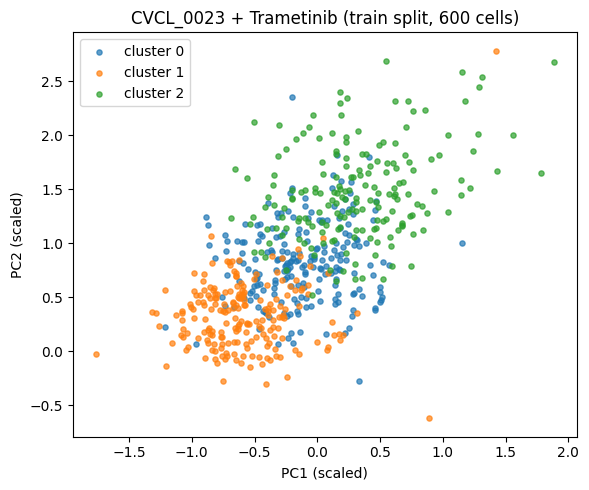

In [ ]:
TARGET_LINE = "CVCL_0023"
TARGET_DRUG = "Trametinib"
# TARGET_LINE_2 = "CVCL_0023"
# TARGET_DRUG_2 = "DMSO_TF"

def pair_scatter(line_name, drug_name):
    if line_name not in manifest["line_names"] or drug_name not in manifest["drug_names"]:
        raise ValueError(
            f"Unknown cell line or drug. Line names containing a similar prefix: "
            f"{[l for l in manifest['line_names'] if line_name[:6] in l]}; "
            f"drug names containing a similar prefix: "
            f"{[d for d in manifest['drug_names'] if drug_name[:4].lower() in d.lower()]}"
        )
    line_id = manifest["line_names"].index(line_name)
    drug_id = manifest["drug_names"].index(drug_name)
    for split, ds in (("train", pca_train_loader.dataset), ("validation", pca_validation_loader.dataset)):
        rows = np.flatnonzero((ds.line_id == line_id) & (ds.drug_id == drug_id))
        if len(rows):
            return split, ds, rows
    raise ValueError(f"No cells found for {line_name} + {drug_name} in either split")


split_name, pair_ds, pair_rows = pair_scatter(TARGET_LINE, TARGET_DRUG)
pair_pcs = pair_ds.pcs[pair_rows].numpy()
pair_cluster = pair_ds.cluster[pair_rows].numpy()

fig, ax = plt.subplots(figsize=(6, 5))
for k in sorted(np.unique(pair_cluster)):
    mask = pair_cluster == k
    ax.scatter(pair_pcs[mask, 0], pair_pcs[mask, 1], s=14, alpha=0.7,
               label=f"cluster {k}" if k >= 0 else "DMSO")

# split_name_2, pair_ds_2, pair_rows_2 = pair_scatter(TARGET_LINE_2, TARGET_DRUG_2)
# pair_pcs_2 = pair_ds_2.pcs[pair_rows_2].numpy()
# pair_cluster_2 = pair_ds_2.cluster[pair_rows_2].numpy()

# for k in sorted(np.unique(pair_cluster_2)):
#     mask = pair_cluster_2 == k
#     ax.scatter(pair_pcs_2[mask, 0], pair_pcs_2[mask, 1], s=14, alpha=0.7,
#                label=f"cluster {k}" if k >= 0 else "DMSO")






ax.set(title=f"{TARGET_LINE} + {TARGET_DRUG} ({split_name} split, {len(pair_rows)} cells)",
       xlabel="PC1 (scaled)", ylabel="PC2 (scaled)")
ax.legend()
plt.tight_layout()
plt.show()


### 7f. Checks
##Just for additional analysis of data, do not need to run this

The streaming PCA is checked against `sklearn.decomposition.PCA` on a sample of training cells, the saved arrays are sanity-checked, and the cluster labels are validated (DMSO = -1, ids in `0..2`, ordering by distance to DMSO, label = nearest centroid). The last cell plots the PCs and checks the PC → expression round trip on validation cells.

50 PCs capture 28.4% of HVG variance (PC1 2.6%, PC10 cumulative 15.6%)


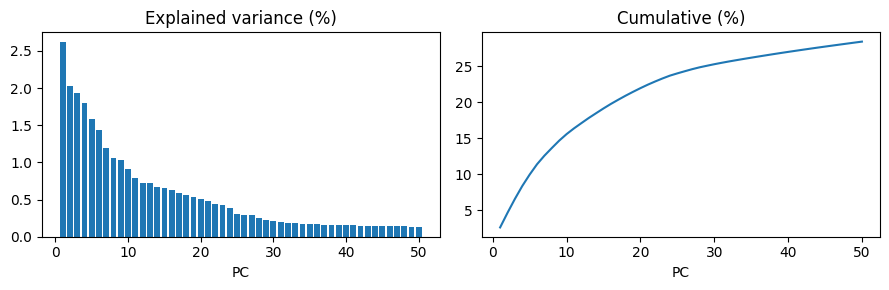

train: 791,249 cells with PCs
validation: 200,650 cells with PCs
validation/train variance per PC, first 10: [0.95 0.92 1.14 1.13 0.91 1.07 0.83 0.82 0.85 0.91]
streaming vs sklearn on 13,526 cells: max |ratio diff| = 7.98e-17, min |cos| over top 5 PCs = 1.0000
full-train PCs vs sample-fit sklearn PCs, |cos| of the top 5: [0.982 0.427 0.425 0.734 0.75 ]


In [ ]:
pca_ratio = pca_model["explained_variance_ratio"]
print(f"{N_PCS} PCs capture {100 * pca_ratio.sum():.1f}% of HVG variance "
      f"(PC1 {100 * pca_ratio[0]:.1f}%, PC10 cumulative {100 * pca_ratio[:10].sum():.1f}%)")
assert not np.isin(pca_model["hvg_ids"], [0, 1]).any(), "special token ids among the HVGs"

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(range(1, N_PCS + 1), 100 * pca_ratio); axes[0].set(title="Explained variance (%)", xlabel="PC")
axes[1].plot(range(1, N_PCS + 1), 100 * np.cumsum(pca_ratio)); axes[1].set(title="Cumulative (%)", xlabel="PC")
plt.tight_layout(); plt.show()

pcs_check = {name: np.load(PCA_DIR / f"pcs_{name}.npy") for name in ("train", "validation")}
for name, values in pcs_check.items():
    rows = np.isfinite(values).all(axis=1)
    if MAX_BATCHES is None:
        expected = len({"train": train_loader, "validation": validation_loader}[name].dataset)
        assert rows.all() and values.shape == (expected, N_PCS)
    print(f"{name}: {rows.sum():,} cells with PCs")
train_pcs_valid = pcs_check["train"][np.isfinite(pcs_check["train"]).all(axis=1)]
val_pcs_valid = pcs_check["validation"][np.isfinite(pcs_check["validation"]).all(axis=1)]
assert np.abs(train_pcs_valid.mean(axis=0) / train_pcs_valid.std(axis=0)).max() < 1e-3, "train PCs not centred"
scaled_std = (train_pcs_valid / pca_model["pc_scale"]).std(dtype=np.float64)
assert abs(scaled_std - 1) < 1e-3, f"scaled train PCs have overall std {scaled_std}"
variance_ratio = val_pcs_valid.var(axis=0) / train_pcs_valid.var(axis=0)
print("validation/train variance per PC, first 10:", np.round(variance_ratio[:10], 2))
if not ((0.5 < variance_ratio[:10]) & (variance_ratio[:10] < 2)).all():
    print("WARNING: validation PC variance differs from train by more than 2x for some leading PCs")

# Cross-check the streaming PCA against sklearn on a sample of ~20k training cells.
sample_loader = make_pass_loader(train_loader.dataset, FIT_BATCH_SIZE, shuffle=True, seed=123)
sample_z = []
for batch_ in islice(sample_loader, max(1, 20000 // FIT_BATCH_SIZE)):
    cell_, genes_, x_, log_x_, b_ = flatten_batch(batch_)
    sample_z.append(standardise(densify_hvg(log_x_, cell_, genes_, b_, pca_model["hvg_col"]),
                                pca_model["scaler_mean"], pca_model["scaler_std"]))
sample_z = np.concatenate(sample_z).astype(np.float64)
mu_s, comps_s, var_s, ratio_s = pca_from_moments(sample_z.sum(0), sample_z.T @ sample_z, len(sample_z), N_PCS)
sk = PCA(n_components=N_PCS, svd_solver="full").fit(sample_z)
assert np.allclose(ratio_s, sk.explained_variance_ratio_, rtol=1e-4, atol=1e-8), "streaming PCA disagrees with sklearn"
cosine = np.abs((comps_s * sk.components_).sum(axis=1))
assert (cosine[:3] > 0.99).all(), cosine[:3]
full_vs_sample = np.abs((pca_model["components"].astype(np.float64) * sk.components_).sum(axis=1))
print(f"streaming vs sklearn on {len(sample_z):,} cells: max |ratio diff| = "
      f"{np.abs(ratio_s - sk.explained_variance_ratio_).max():.2e}, min |cos| over top 5 PCs = {cosine[:5].min():.4f}")
print("full-train PCs vs sample-fit sklearn PCs, |cos| of the top 5:", np.round(full_vs_sample[:5], 3))


In [ ]:
cluster_check = {name: np.load(PCA_DIR / f"cluster_{name}.npy") for name in ("train", "validation")}
for name, labels in cluster_check.items():
    dataset = {"train": train_loader, "validation": validation_loader}[name].dataset
    finite = np.isfinite(pcs_check[name]).all(axis=1)
    is_dmso = dataset.index["drug_id"] == 0
    assert (labels[is_dmso] == -1).all(), "DMSO cells must have cluster -1"
    treated_labels = labels[~is_dmso & finite]
    assert ((treated_labels >= 0) & (treated_labels < CLUSTER_K)).all(), "treated cells need a cluster in 0..k-1"
    per_pair = pd.DataFrame({"line": dataset.index["line_id"], "drug": dataset.index["drug_id"], "cluster": labels})
    per_pair = per_pair[~is_dmso & finite].groupby(["line", "drug"])["cluster"].agg(n_cells="size", n_clusters="nunique")
    print(f"{name}: {len(per_pair)} treated pairs; clusters per pair {per_pair['n_clusters'].value_counts().sort_index().to_dict()}; "
          f"cells per cluster {np.bincount(treated_labels).tolist()}")

# Ordering: distance to the DMSO reference should grow with cluster id; labels should match the nearest centroid.
reference = pca_model["dmso_reference"]
train_dataset = train_loader.dataset
n_drugs = len(manifest["drug_names"])
labels, finite = cluster_check["train"], np.isfinite(pcs_check["train"]).all(axis=1)
treated = np.flatnonzero((labels >= 0) & finite)
distance = np.linalg.norm(pcs_check["train"][treated] - reference[train_dataset.index["line_id"][treated]], axis=1)
print("mean distance to DMSO centroid by cluster id (train):",
      [round(float(distance[labels[treated] == k].mean()), 2) for k in range(CLUSTER_K)])
pair_key = train_dataset.index["line_id"][treated].astype(np.int64) * n_drugs + train_dataset.index["drug_id"][treated]
unique_keys = np.unique(pair_key)
agree = []
for key in np.random.default_rng(0).choice(unique_keys, size=min(10, len(unique_keys)), replace=False):
    rows = treated[pair_key == key]
    ids = np.unique(labels[rows])
    if len(ids) < 2:
        continue
    centroids = np.stack([pcs_check["train"][rows[labels[rows] == k]].mean(axis=0) for k in ids])
    nearest = ids[np.linalg.norm(pcs_check["train"][rows][:, None] - centroids[None], axis=2).argmin(axis=1)]
    agree.append((nearest == labels[rows]).mean())
print(f"label == nearest centroid for {100 * np.mean(agree):.1f}% of cells in {len(agree)} sampled pairs")
assert np.mean(agree) > 0.99


train: 2000 treated pairs; clusters per pair {3: 2000}; cells per cluster [269698, 228138, 183981]
validation: 500 treated pairs; clusters per pair {3: 500}; cells per cluster [69343, 57847, 45918]
mean distance to DMSO centroid by cluster id (train): [7.79, 9.46, 11.33]
label == nearest centroid for 100.0% of cells in 10 sampled pairs


In [ ]:
train_pc_ds = pca_train_loader.dataset
n_drugs = len(manifest["drug_names"])
sample_rows = np.random.default_rng(0).choice(len(train_pc_ds), size=min(20000, len(train_pc_ds)), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
coords = train_pc_ds.pcs[sample_rows].numpy()
axes[0].scatter(coords[:, 0], coords[:, 1], c=train_pc_ds.is_control[sample_rows].numpy(), s=2, cmap="coolwarm")
axes[0].set(title="Train sample: PC1 vs PC2 (red = DMSO)", xlabel="PC1 (scaled)", ylabel="PC2 (scaled)")
pc_pair_key = train_pc_ds.line_id * n_drugs + train_pc_ds.drug_id
pc_pair_key = np.where(train_pc_ds.drug_id != 0, pc_pair_key, -1)
big_line, big_drug = divmod(int(np.bincount(pc_pair_key[pc_pair_key >= 0]).argmax()), n_drugs)
pair_rows = np.flatnonzero((train_pc_ds.line_id == big_line) & (train_pc_ds.drug_id == big_drug))
pair_xy = train_pc_ds.pcs[pair_rows].numpy()
axes[1].scatter(pair_xy[:, 0], pair_xy[:, 1], c=train_pc_ds.cluster[pair_rows].numpy(), s=8, cmap="viridis")
axes[1].set(title=f"{manifest['line_names'][big_line]} + {manifest['drug_names'][big_drug]}: cluster ids",
            xlabel="PC1 (scaled)", ylabel="PC2 (scaled)")
plt.tight_layout(); plt.show()

# Round trip: PCs -> HVG log-normalised expression for a few validation cells, and reconstruction error by number of PCs.
val_loader_rt = make_pass_loader(validation_loader.dataset, FIT_BATCH_SIZE, shuffle=True, seed=7)
true_log, true_z = [], []
for batch_ in islice(val_loader_rt, 8):
    cell_, genes_, x_, log_x_, b_ = flatten_batch(batch_)
    dense_ = densify_hvg(log_x_, cell_, genes_, b_, pca_model["hvg_col"])
    true_log.append(dense_)
    true_z.append(standardise(dense_, pca_model["scaler_mean"], pca_model["scaler_std"]))
true_log, true_z = np.concatenate(true_log), np.concatenate(true_z)
raw_pcs = (true_z - pca_model["pca_mean"]) @ pca_model["components"].T
recon_log = pcs_to_hvg_expression(raw_pcs / pca_model["pc_scale"], pca_model)
corr = np.mean([np.corrcoef(a, b)[0, 1] for a, b in zip(true_log[:500], recon_log[:500])])
print(f"validation cells: mean per-cell correlation, true vs reconstructed log-normalised HVGs = {corr:.3f}")
for k in (5, 10, 25, N_PCS):
    z_hat = raw_pcs[:, :k] @ pca_model["components"][:k] + pca_model["pca_mean"]
    print(f"  {k:>2} PCs: mean squared error on standardised HVGs = {np.mean((z_hat - true_z) ** 2):.4f}")


Run this to export all PCA data needed to run the dataloader in another notebook

In [ ]:
!zip -r /content/25lines_100drugs_pca_data.zip /content/data

# 2. Download the zip file to your local computer
from google.colab import files
files.download('/content/25lines_100drugs_pca_data.zip')

  adding: content/data/ (stored 0%)
  adding: content/data/Tahoe/ (stored 0%)
  adding: content/data/Tahoe/subsets/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/sample_metadata.parquet (deflated 20%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/cell_line_metadata.parquet (deflated 34%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/gene_metadata.parquet (deflated 38%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/drug_metadata.parquet (deflated 21%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/selected_cells.parquet (deflated 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/plan.json (deflated 61%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/download_status.json (deflated 39%)
  adding: content/data/Tah

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r /content/25lines_100drugs_pca_data.zip /content/data -x "*.parquet" "*/.parquet" "*/*.parquet"

  adding: content/data/ (stored 0%)
  adding: content/data/Tahoe/ (stored 0%)
  adding: content/data/Tahoe/subsets/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/plan.json (deflated 61%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/download_status.json (deflated 39%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/download_progress.json (deflated 96%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/coverage_report.json (deflated 94%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/ (stored 0%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/manifest.json (deflated 90%)
  adding: content/data/Tahoe/subsets/cfg_25lines_100drugs/

In [ ]:
def backfill_pca_labels(pca_dir=PCA_DIR):
    manifest_path = pca_dir / "pca_manifest.json"
    saved = json.loads(manifest_path.read_text())
    files = list(saved["files"])
    for name, ds in (("train", train_loader.dataset), ("validation", validation_loader.dataset)):
        for kind in ("line_id", "drug_id"):
            file_path = pca_dir / f"{kind}_{name}.npy"
            if not file_path.exists():
                atomic_npy(file_path, ds.index[kind].astype(np.int16))
            if file_path.name not in files:
                files.append(file_path.name)
    saved["line_names"] = manifest["line_names"]
    saved["drug_names"] = manifest["drug_names"]
    saved["files"] = files
    atomic_json(manifest_path, saved)
    print("Backfilled label files into", pca_dir, "-- no PCA refit needed")


backfill_pca_labels()


Backfilled label files into /content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000 -- no PCA refit needed
